# CSMODEL MP Phase 1

In [310]:
# Import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Importing

In [311]:
# Defining data for the dataframe
LFS_df = pd.read_csv('LFSPUFApril2016.CSV', dtype=pd.StringDtype())
LFS_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180862 entries, 0 to 180861
Data columns (total 50 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   PUFREG           180862 non-null  string
 1   PUFPRV           180862 non-null  string
 2   PUFPRRCD         180862 non-null  string
 3   PUFHHNUM         180862 non-null  string
 4   PUFURB2K10       180862 non-null  string
 5   PUFPWGTFIN       180862 non-null  string
 6   PUFSVYMO         180862 non-null  string
 7   PUFSVYYR         180862 non-null  string
 8   PUFPSU           180862 non-null  string
 9   PUFRPL           180862 non-null  string
 10  PUFHHSIZE        180862 non-null  string
 11  PUFC01_LNO       180862 non-null  string
 12  PUFC03_REL       180862 non-null  string
 13  PUFC04_SEX       180862 non-null  string
 14  PUFC05_AGE       180862 non-null  string
 15  PUFC06_MSTAT     180862 non-null  string
 16  PUFC07_GRADE     180862 non-null  string
 17  PUFC08_CUR

# Dataset Description

# Data Cleaning

In [312]:

# PUFC05_AGE
LFS_df['PUFC05_AGE'] = LFS_df['PUFC05_AGE'].astype(int)
LFS_df = LFS_df[LFS_df['PUFC05_AGE'] >= 15]

# PUFC10_CONWR_VS1
LFS_df['PUFC10_CONWR'] = LFS_df['PUFC10_CONWR'].replace({
        # ' ':'Below Working Age', <-- not needed
        '1':'OCW',
        '2':'not OCW worker',
        '3':'diplomatic',
        '4':'student or tourist',
        '5':'other'
})

# PUFC14_PROCC_VS2
LFS_df['PUFC14_PROCC'] = LFS_df['PUFC14_PROCC'].replace({
        '  ' :  'None',
        '01' :	'Armed Forces Occupations',
        '02' :	'Armed Forces Occupations',
        '03' :	'Armed Forces Occupations',
        '11' :	'Managers',
        '12' :	'Managers',
        '13' :	'Managers',
        '14' :	'Managers',
        '21' :	'Professionals',
        '22' :	'Professionals',
        '23' :	'Professionals',
        '24' :	'Professionals',
        '25' :	'Professionals',
        '26' :	'Professionals',
        '31' :	'Technicians and Associate Professionals',
        '32' :	'Technicians and Associate Professionals',
        '33' :	'Technicians and Associate Professionals',
        '34' :	'Technicians and Associate Professionals',
        '35' :	'Technicians and Associate Professionals',
        '41' :	'Clerical Support Workers',
        '42' :	'Clerical Support Workers',
        '43' :  'Clerical Support Workers',
        '44' :	'Clerical Support Workers',
        '51' :	'Service and Sales Workers',
        '52' :	'Service and Sales Workers',
        '53' :	'Service and Sales Workers',
        '54' :	'Service and Sales Workers',
        '61' :	'Skilled Agricultural, Forestry and Fishery Workers',
        '62' :	'Skilled Agricultural, Forestry and Fishery Workers',
        '63' :	'Skilled Agricultural, Forestry and Fishery Workers',
        '71' :	'Craft and Related Trades Workers',
        '72' :	'Craft and Related Trades Workers',
        '73' :	'Craft and Related Trades Workers',
        '74' :	'Craft and Related Trades Workers',
        '75' :	'Craft and Related Trades Workers',
        '81' :	'Plant and Machine Operators and Assemblers',
        '82' :	'Plant and Machine Operators and Assemblers',
        '83' :	'Plant and Machine Operators and Assemblers',
        '91' :	'Elementary Occupations',
        '92' :	'Elementary Occupations',
        '93' :	'Elementary Occupations',
        '94' :	'Elementary Occupations',
        '95' :	'Elementary Occupations',
        '96' :	'Elementary Occupations',
})

# PUFC16_PKB_VS2
indu_list = [str(x) for x in range(10, 44)]
serv_list = [str(x) for x in range(45, 100)]
LFS_df['PUFC16_PKB'] = LFS_df['PUFC16_PKB'].replace(indu_list, "Industry")
LFS_df['PUFC16_PKB'] = LFS_df['PUFC16_PKB'].replace(serv_list, "Services")
LFS_df['PUFC16_PKB'] = LFS_df['PUFC16_PKB'].replace({
        '  ':'None',
        '01' : 'Agriculture',
        '02' : 'Agriculture'	,
        '03' : 'Agriculture'	,
        '05' : 'Industry'	,
        '06' : 'Industry'	,
        '07' : 'Industry'	,
        '08' : 'Industry'	,
        '09' : 'Industry'	,
                                                     })

LFS_df['PUFC10_CONWR'].unique()
LFS_df['PUFC14_PROCC'].unique()
LFS_df['PUFC16_PKB'].unique()
LFS_df.groupby('PUFC05_AGE')['PUFC25_PBASIC'].value_counts()
LFS_df['PUFC16_PKB'].info()

<class 'pandas.core.series.Series'>
Index: 123080 entries, 0 to 180861
Series name: PUFC16_PKB
Non-Null Count   Dtype 
--------------   ----- 
123080 non-null  string
dtypes: string(1)
memory usage: 1.9 MB


### Cleaning educational-background columns

In [313]:
LFS_df['PUFC07_GRADE']

0         350
1         350
2         350
3         320
4         350
         ... 
180850    000
180851    000
180857    350
180858    830
180861    350
Name: PUFC07_GRADE, Length: 123080, dtype: string

In [314]:
LFS_df['PUFC07_GRADE'].str.isspace().sum() # no spaces

np.int64(0)

In [315]:
(LFS_df['PUFC07_GRADE'].isna() == 1).sum() # no null values

np.int64(0)

In [316]:
LFS_df['PUFC07_GRADE'] = LFS_df['PUFC07_GRADE'].astype('object')

elementary = ['210','220','230','240','250','260'] # correct
highschool = ['310','320','330','340'] # correct
post_secondary = ['410','420']
post_secondary_grads = ['501', '508', '509', '514', '521', '522', '531', '532', '534', '542', 
               '544', '548', '552', '554', '558', '562', '564', '572', '576', '581', 
               '584', '585', '586', '589']
college = ['810','820','830','840'] # correct
college_graduate = ["601", "614", "621", "622", "631", "632", "634", "638",
    "642", "644", "646", "648", "652", "654", "658", "662",
    "664", "672", "676", "681", "684", "685", "686", "689"]

single_map = {
    '000': 0, # correct
    '010': 1, # correct
    '280': 3, # correct
    '350': 5, # correct
    '900': 10 # correct
}
LFS_df['PUFC07_GRADE'] = LFS_df['PUFC07_GRADE'].replace(single_map)

LFS_df.loc[LFS_df['PUFC07_GRADE'].isin(elementary),             'PUFC07_GRADE'] = 2
LFS_df.loc[LFS_df['PUFC07_GRADE'].isin(highschool),             'PUFC07_GRADE'] = 4
LFS_df.loc[LFS_df['PUFC07_GRADE'].isin(post_secondary),         'PUFC07_GRADE'] = 6
LFS_df.loc[LFS_df['PUFC07_GRADE'].isin(post_secondary_grads),   'PUFC07_GRADE'] = 7
LFS_df.loc[LFS_df['PUFC07_GRADE'].isin(college),                'PUFC07_GRADE'] = 8
LFS_df.loc[LFS_df['PUFC07_GRADE'].isin(college_graduate),       'PUFC07_GRADE'] = 9

In [317]:
unique_gradecompleted = LFS_df['PUFC07_GRADE'].unique()
unique_gradecompleted

array([5, 4, 9, 2, 3, 10, 8, 7, 0, 6, 1], dtype=object)

In [318]:
LFS_df['PUFC09_GRADTECH']

0         2
1         2
2         2
3         2
4         2
         ..
180850    2
180851    2
180857    2
180858    2
180861    2
Name: PUFC09_GRADTECH, Length: 123080, dtype: string

In [319]:
LFS_df['PUFC09_GRADTECH'].str.isspace().sum()

np.int64(0)

In [320]:
(LFS_df[(LFS_df['PUFC05_AGE'] < 15) & (LFS_df['PUFC09_GRADTECH'] == ' ')]).shape

(0, 50)

In [321]:
LFS_df['PUFC09_GRADTECH'].unique()

<StringArray>
['2', '1']
Length: 2, dtype: string

In [322]:
LFS_df['PUFC09_GRADTECH'] = LFS_df['PUFC09_GRADTECH'].astype(int)

# Research Question and Exploratory Data Analysis

In [323]:
list(LFS_df.columns)

['PUFREG',
 'PUFPRV',
 'PUFPRRCD',
 'PUFHHNUM',
 'PUFURB2K10',
 'PUFPWGTFIN',
 'PUFSVYMO',
 'PUFSVYYR',
 'PUFPSU',
 'PUFRPL',
 'PUFHHSIZE',
 'PUFC01_LNO',
 'PUFC03_REL',
 'PUFC04_SEX',
 'PUFC05_AGE',
 'PUFC06_MSTAT',
 'PUFC07_GRADE',
 'PUFC08_CURSCH',
 'PUFC09_GRADTECH',
 'PUFC10_CONWR',
 'PUFC11_WORK',
 'PUFC12_JOB',
 'PUFC14_PROCC',
 'PUFC16_PKB',
 'PUFC17_NATEM',
 'PUFC18_PNWHRS',
 'PUFC19_PHOURS',
 'PUFC20_PWMORE',
 'PUFC21_PLADDW',
 'PUFC22_PFWRK',
 'PUFC23_PCLASS',
 'PUFC24_PBASIS',
 'PUFC25_PBASIC',
 'PUFC26_OJOB',
 'PUFC27_NJOBS',
 'PUFC28_THOURS',
 'PUFC29_WWM48H',
 'PUFC30_LOOKW',
 'PUFC31_FLWRK',
 'PUFC32_JOBSM',
 'PUFC33_WEEKS',
 'PUFC34_WYNOT',
 'PUFC35_LTLOOKW',
 'PUFC36_AVAIL',
 'PUFC37_WILLING',
 'PUFC38_PREVJOB',
 'PUFC40_POCC',
 'PUFC41_WQTR',
 'PUFC43_QKB',
 'PUFNEWEMPSTAT']

In [324]:
LFS_df['PUFC14_PROCC'].unique()

<StringArray>
['Skilled Agricultural, Forestry and Fishery Workers',
                             'Elementary Occupations',
                          'Service and Sales Workers',
                                               'None',
                                           'Managers',
                   'Craft and Related Trades Workers',
         'Plant and Machine Operators and Assemblers',
            'Technicians and Associate Professionals',
                           'Clerical Support Workers',
                                      'Professionals',
                           'Armed Forces Occupations']
Length: 11, dtype: string

In [325]:
LFS_df[['PUFC09_GRADTECH', 'PUFC14_PROCC']]

,PUFC09_GRADTECH,PUFC14_PROCC
0,2,"Skilled Agricultural, Forestry and Fishery Wor..."
1,2,Elementary Occupations
2,2,Elementary Occupations
3,2,"Skilled Agricultural, Forestry and Fishery Wor..."
4,2,Elementary Occupations
...,...,...
180850,2,"Skilled Agricultural, Forestry and Fishery Wor..."
180851,2,"Skilled Agricultural, Forestry and Fishery Wor..."
180857,2,Managers
180858,2,None


In [326]:
LFS_df['PUFNEWEMPSTAT'].unique()

<StringArray>
['1', '3', '2', ' ']
Length: 4, dtype: string

In [327]:
LFS_df['PUFNEWEMPSTAT'].str.isspace().sum()

np.int64(3555)

In [328]:
LFS_df = LFS_df[LFS_df['PUFNEWEMPSTAT'] != ' ']
LFS_df['PUFNEWEMPSTAT'].str.isspace().sum()

np.int64(0)

In [329]:
LFS_df['PUFNEWEMPSTAT'] = LFS_df['PUFNEWEMPSTAT'].astype(int)

In [330]:
(LFS_df['PUFNEWEMPSTAT'] == 3).sum()

np.int64(43877)

In [331]:
(LFS_df['PUFNEWEMPSTAT'] != 3).sum()

np.int64(75648)

In [332]:
LFS_df.shape

(119525, 50)

In [333]:
LFS_df = LFS_df[LFS_df['PUFNEWEMPSTAT'] != 3]

In [334]:
LFS_df.shape

(75648, 50)

In [335]:
LFS_df['PUFNEWEMPSTAT'].unique()

array([1, 2])

In [336]:
(LFS_df['PUFNEWEMPSTAT'] == 2).sum()

np.int64(4293)

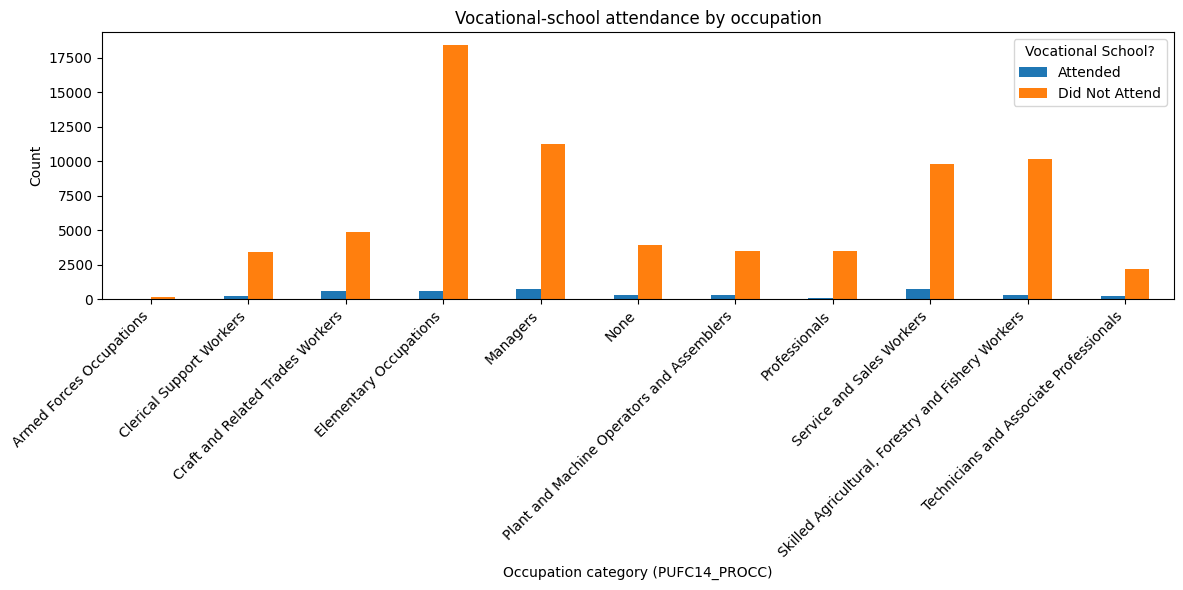

In [337]:
# 1) aggregate counts
counts = (
    LFS_df
    .groupby(["PUFC14_PROCC", "PUFC09_GRADTECH"])
    .size()
    .unstack(fill_value=0)
    .rename(columns={1: "Attended", 2: "Did Not Attend"})
)

# 2) plot grouped bar chart
ax = counts.plot(
    kind="bar",
    figsize=(12, 6),
)
ax.set_xlabel("Occupation category (PUFC14_PROCC)")
ax.set_ylabel("Count")
ax.set_title("Vocational-school attendance by occupation")
ax.legend(title="Vocational School?")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [338]:
LFS_df.shape

(75648, 50)

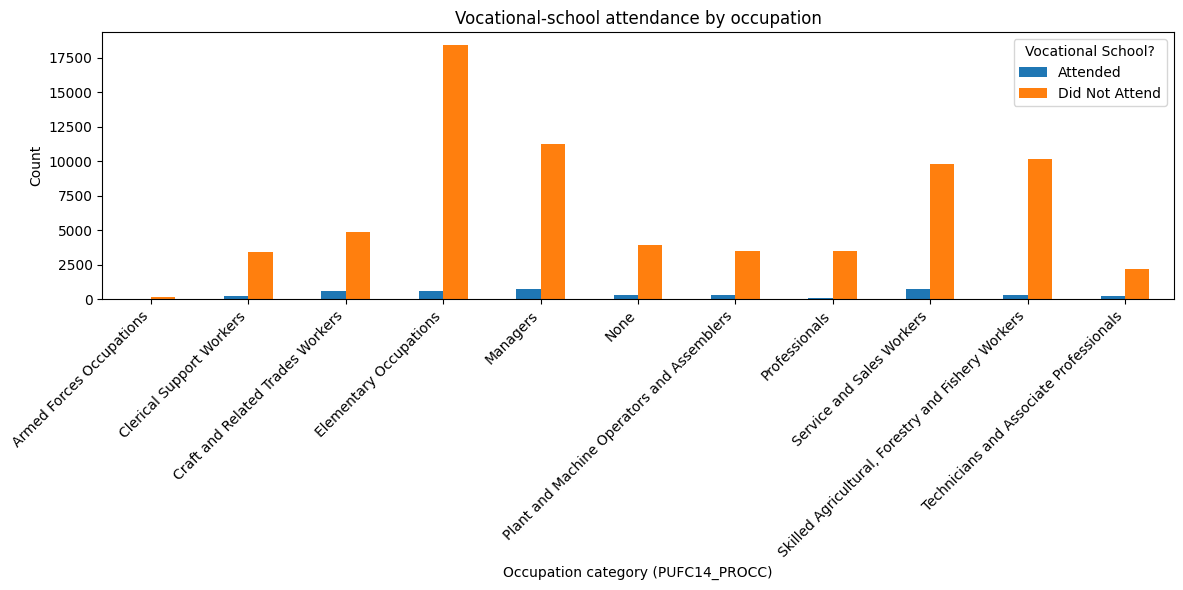

In [339]:
import matplotlib.pyplot as plt

# 1) aggregate counts
counts = (
    LFS_df
    .groupby(["PUFC14_PROCC", "PUFC09_GRADTECH"])
    .size()
    .unstack(fill_value=0)
    .rename(columns={1: "Attended", 2: "Did Not Attend"})
)

# 2) plot grouped bar chart
ax = counts.plot(
    kind="bar",
    figsize=(12, 6),
)
ax.set_xlabel("Occupation category (PUFC14_PROCC)")
ax.set_ylabel("Count")
ax.set_title("Vocational-school attendance by occupation")
ax.legend(title="Vocational School?")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [340]:
LFS_df[(LFS_df['PUFNEWEMPSTAT'] == 2) & (LFS_df['PUFC14_PROCC'] == 'None')].shape

(4293, 50)

In [341]:
LFS_df[(LFS_df['PUFNEWEMPSTAT'] == 2) & (LFS_df['PUFC14_PROCC'] != 'None')].shape

(0, 50)

In [342]:
LFS_df[(LFS_df['PUFNEWEMPSTAT'] == 2)].shape

(4293, 50)

In [343]:
LFS_df = LFS_df[LFS_df['PUFNEWEMPSTAT'] != 2]

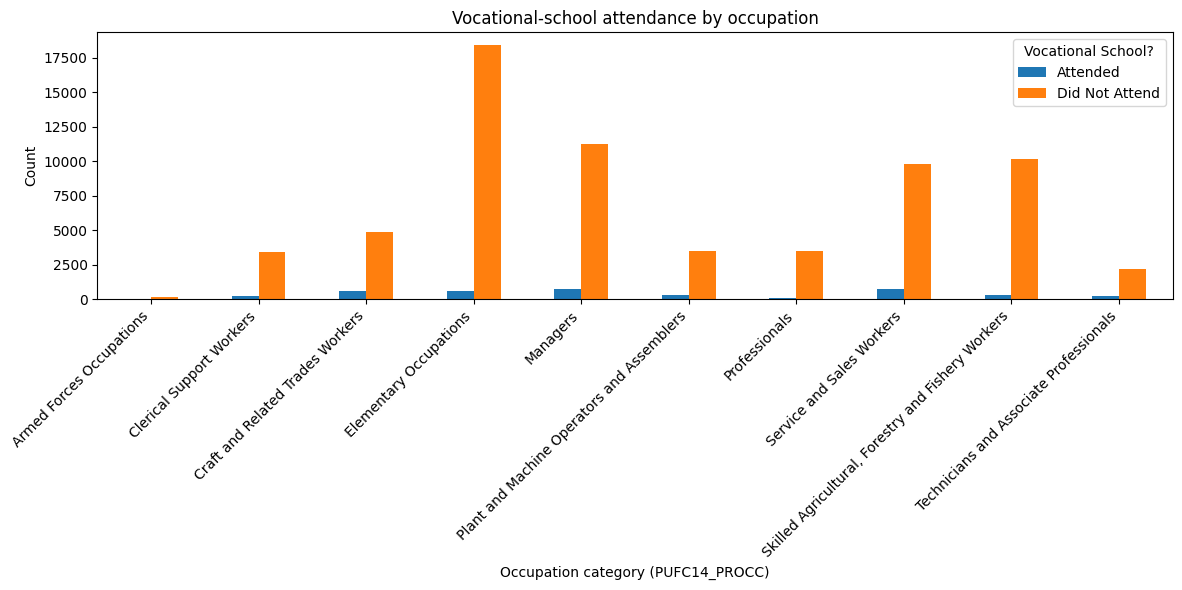

In [344]:
import matplotlib.pyplot as plt

# 1) aggregate counts
counts = (
    LFS_df
    .groupby(["PUFC14_PROCC", "PUFC09_GRADTECH"])
    .size()
    .unstack(fill_value=0)
    .rename(columns={1: "Attended", 2: "Did Not Attend"})
)

# 2) plot grouped bar chart
ax = counts.plot(
    kind="bar",
    figsize=(12, 6),
)
ax.set_xlabel("Occupation category (PUFC14_PROCC)")
ax.set_ylabel("Count")
ax.set_title("Vocational-school attendance by occupation")
ax.legend(title="Vocational School?")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [345]:
LFS_df["PUFC18_PNWHRS"] = LFS_df["PUFC18_PNWHRS"].astype(int)

C:\Users\Jericho\AppData\Local\Temp\ipykernel_10784\2840199401.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


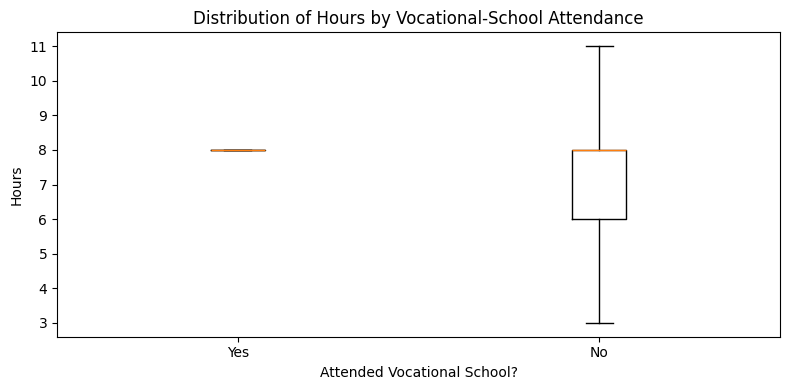

In [346]:
import matplotlib.pyplot as plt

# 1) extract the two series
yes_hours = LFS_df.loc[LFS_df["PUFC09_GRADTECH"] == 1, "PUFC18_PNWHRS"]
no_hours  = LFS_df.loc[LFS_df["PUFC09_GRADTECH"] == 2, "PUFC18_PNWHRS"]

# 2) boxplot of a list of arrays
fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot(
    [yes_hours, no_hours],
    labels=["Yes", "No"],
    showfliers=False          # show outliers — you can turn this off if you like
)
ax.set_xlabel("Attended Vocational School?")
ax.set_ylabel("Hours")
ax.set_title("Distribution of Hours by Vocational‐School Attendance")
plt.tight_layout()
plt.show()


In [347]:
LFS_df[(LFS_df["PUFC09_GRADTECH"] == 1) & ( LFS_df["PUFC18_PNWHRS"] == 8)].shape[0]

2193

In [348]:
(LFS_df["PUFC09_GRADTECH"] == 1).sum()

np.int64(3931)

In [349]:
LFS_df[(LFS_df["PUFC09_GRADTECH"] == 2) & ( LFS_df["PUFC18_PNWHRS"] != 8)].shape[0]

34082

In [350]:
LFS_df[(LFS_df["PUFC09_GRADTECH"] == 1) & ( LFS_df["PUFC18_PNWHRS"] != 8)].describe()

,PUFC05_AGE,PUFC09_GRADTECH,PUFC18_PNWHRS,PUFNEWEMPSTAT
count,1738.000000,1738.0,1738.000000,1738.0
mean,39.971807,1.0,7.396433,1.0
std,13.612949,0.0,3.741493,0.0
min,16.000000,1.0,1.000000,1.0
25%,28.250000,1.0,4.000000,1.0
50%,39.000000,1.0,6.000000,1.0
75%,50.000000,1.0,10.000000,1.0
max,82.000000,1.0,16.000000,1.0


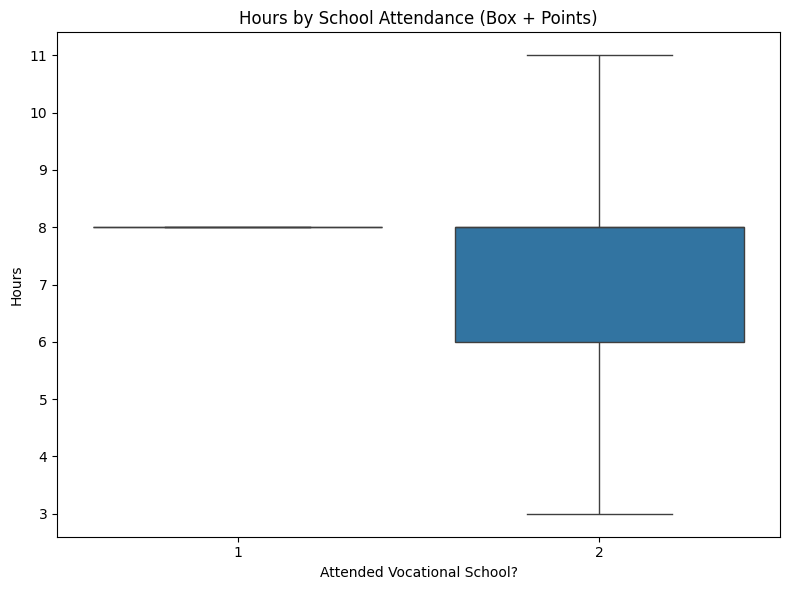

In [351]:
plt.figure(figsize=(8,6))
sns.boxplot(
    data=LFS_df,
    x="PUFC09_GRADTECH",
    y="PUFC18_PNWHRS",
    showfliers=False,    # hide extreme point markers
)

plt.xlabel("Attended Vocational School?")
plt.ylabel("Hours")
plt.title("Hours by School Attendance (Box + Points)")
plt.tight_layout()
plt.show()


# Does a higher grade completed correlate to higher basic pay per day?
For this question, we will mainly need column 7, which is highest grade completed, and column 25, which lists the average basic pay per day.

In [352]:
# copying over
LFS_df['PUFC25_PBASIC'] = pd.to_numeric(LFS_df['PUFC25_PBASIC'], errors='coerce')

First, we copy over the relevant categories.

In [353]:
wage_cat_df = LFS_df[['PUFC07_GRADE', 'PUFC25_PBASIC', 'PUFNEWEMPSTAT']] # copy
wage_cat_df = wage_cat_df[wage_cat_df['PUFNEWEMPSTAT'] != 3] # remove 3

Next, we aggregate the dataset to show the mean, median and standard deviation. As seen below, most groups have very different values for median and mean, indicating skewness.

In [354]:
# check median
median_wage_cat_df = wage_cat_df.groupby('PUFC07_GRADE').agg({'PUFC25_PBASIC': ['median', 'mean', 'std']})
median_wage_cat_df.sort_values(('PUFC25_PBASIC', 'median'), ascending=True)

PUFC25_PBASIC                         
                    median         mean         std
PUFC07_GRADE                                       
0                    200.0   196.065502  101.141121
2                    200.0   231.675583  129.751836
3                    250.0   247.536813  129.803571
4                    250.0   255.817126  138.023278
1                    275.0        237.5  109.381377
5                    300.0   308.676867  166.883403
6                    346.0   362.738693  167.684113
8                    350.0   394.476029  257.986233
7                    357.0   426.566904   279.11411
9                    615.0   732.426852  791.293757
10                  1045.0  1284.132296  783.223581

Now we visualized the data with a boxplot. Before doing this however, we capped basic salary per day to PHP 10000, as on prior inspection there indeed was a massive outlier with a salary greater than PHP 50000.

In [355]:
wage_cat_df.loc[wage_cat_df['PUFC25_PBASIC'] > 10000, 'PUFC25_PBASIC'] = 10000

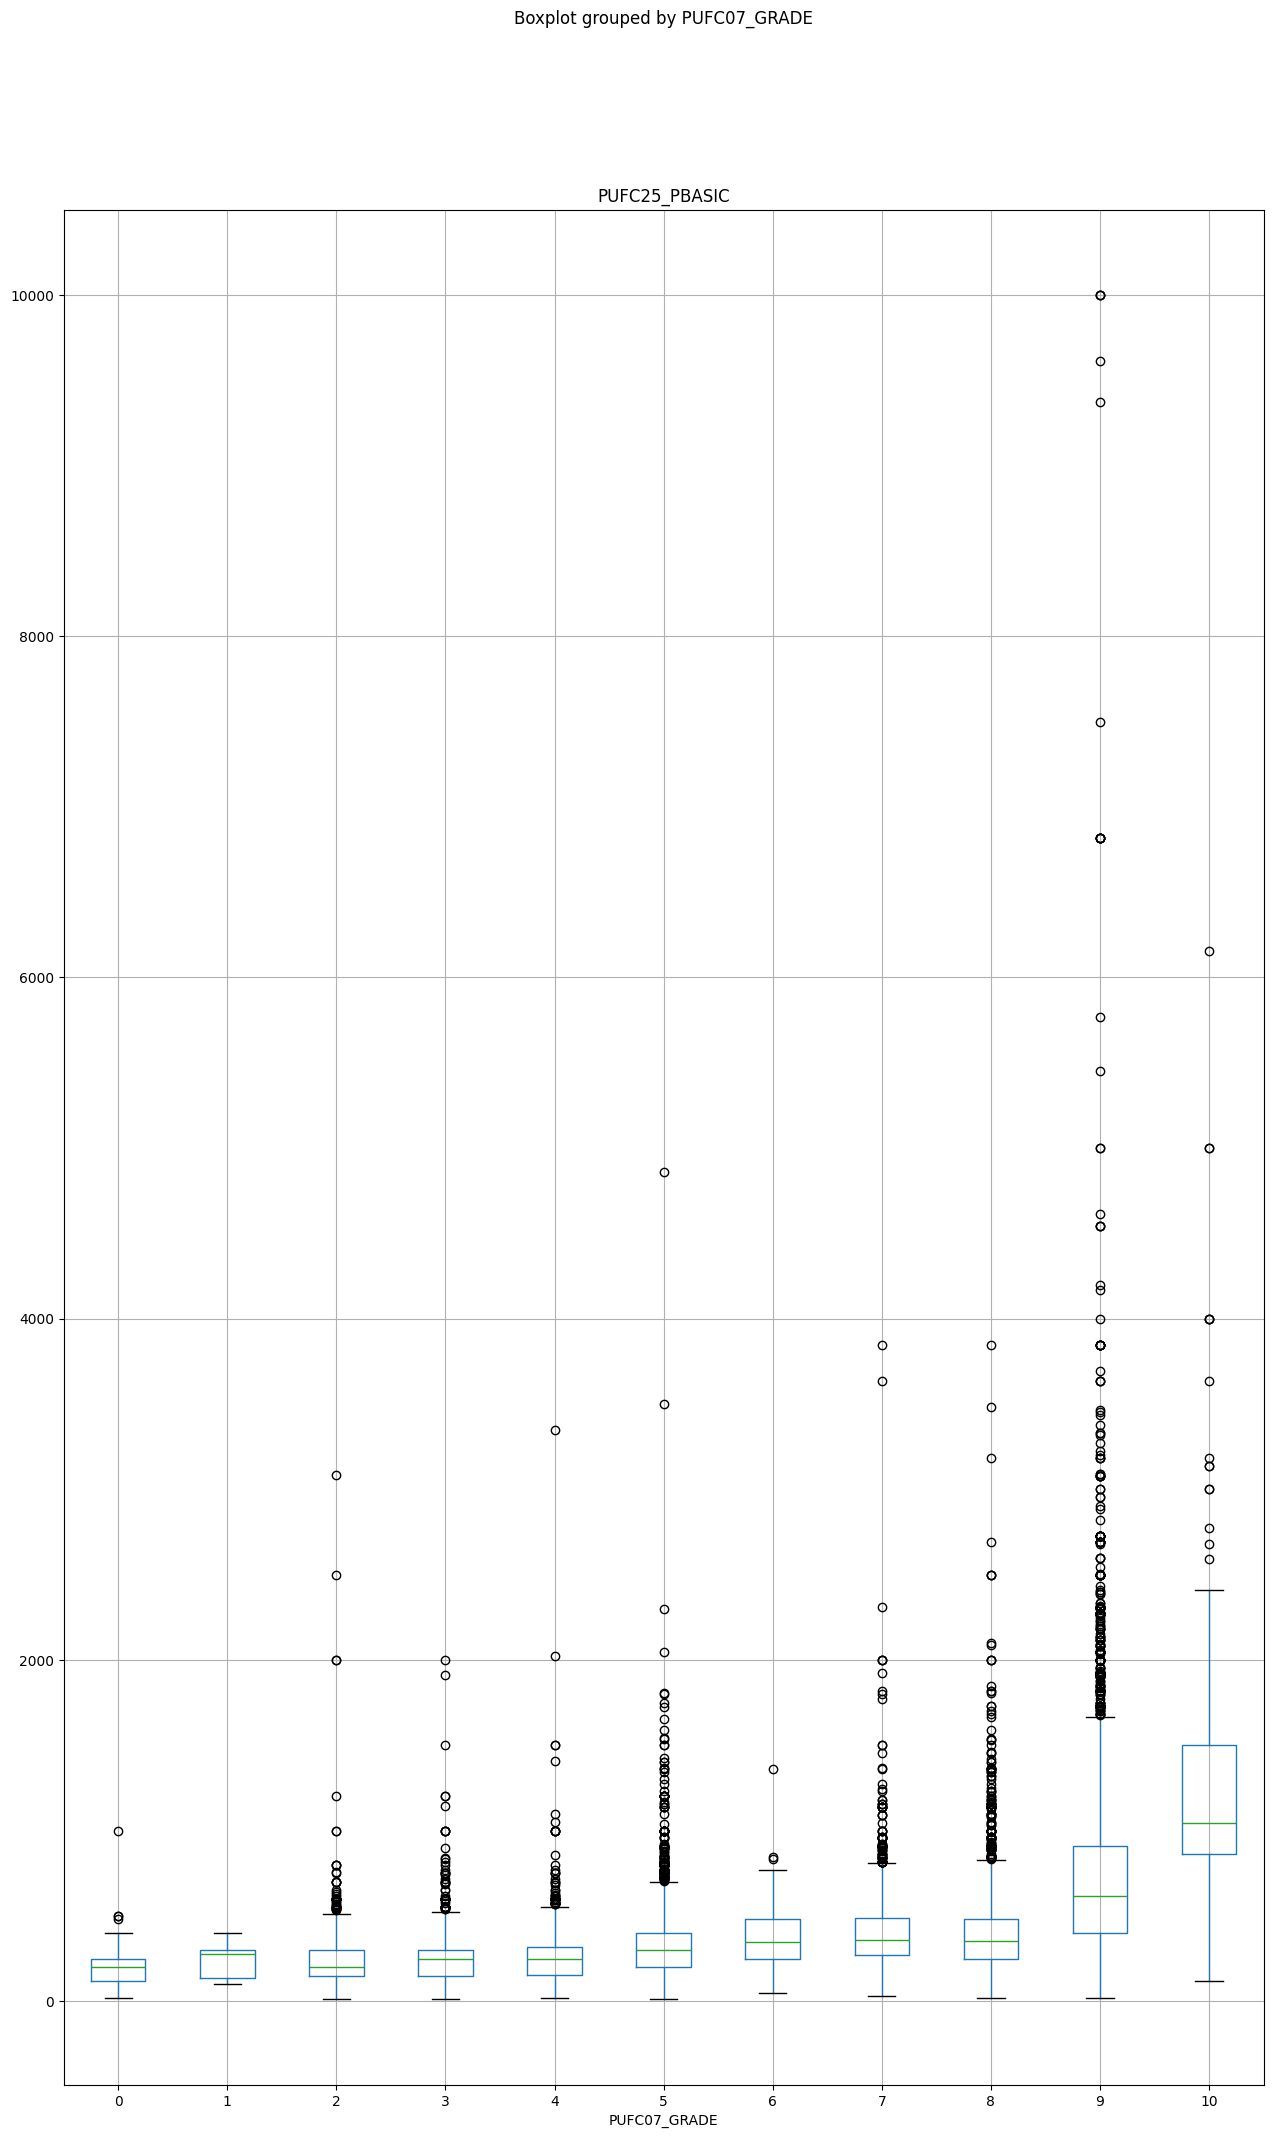

In [356]:
wage_cat_df.boxplot('PUFC25_PBASIC', by='PUFC07_GRADE', figsize=(15, 25))
plt.show()

As seen above, we see that there is a correlation between education level and salary, especially upon finishing higher education. We can verify this observation with a Pearson correlation.

In [357]:
# check correlation
grade_basicpay = wage_cat_df[['PUFC07_GRADE', 'PUFC25_PBASIC']]
grade_basicpay.corr()

,PUFC07_GRADE,PUFC25_PBASIC
PUFC07_GRADE,1.0000,0.4744
PUFC25_PBASIC,0.4744,1.0000


As seen above, the two columns have a moderate positive correlation. As further supporting evidence, we can use a violin plot to check for the density distribution.

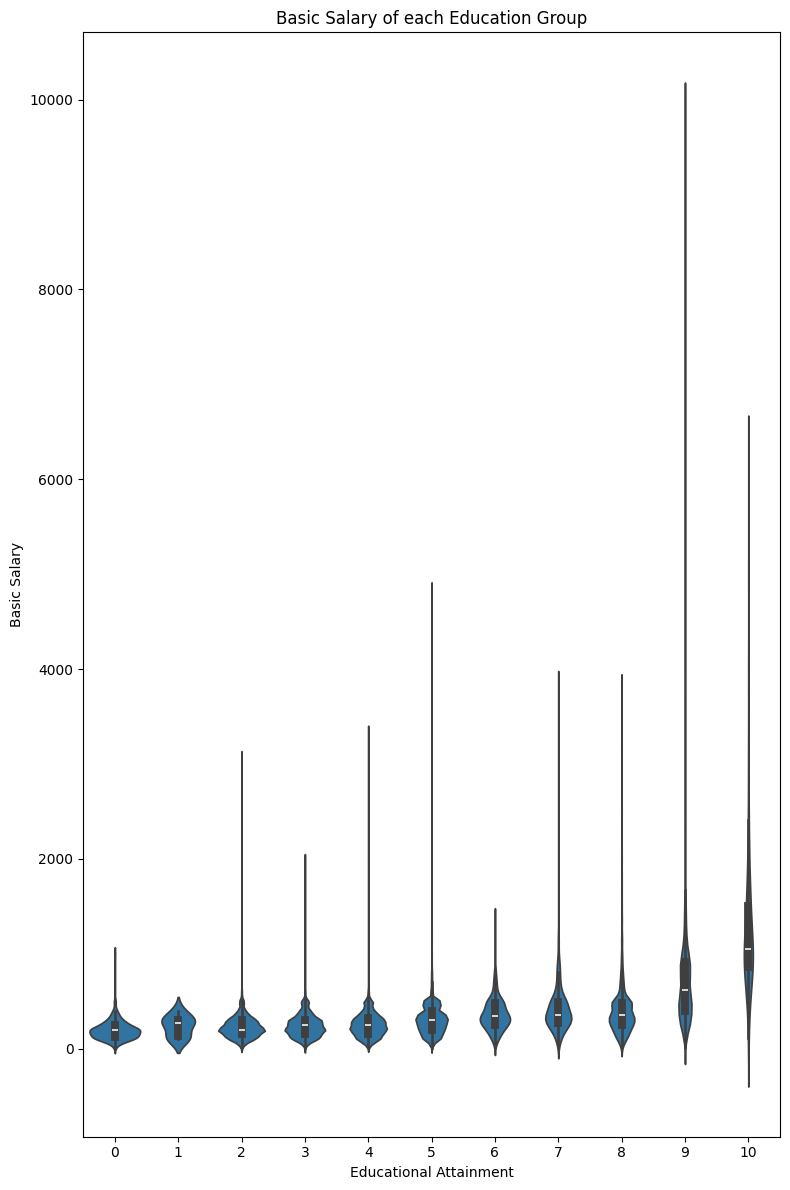

In [358]:
plt.figure(figsize=(8, 12))
sns.violinplot(
    data=grade_basicpay,
    x="PUFC07_GRADE",
    y="PUFC25_PBASIC" # hide extreme point markers
)

plt.xlabel("Educational Attainment")
plt.ylabel("Basic Salary")
plt.title("Basic Salary of each Education Group")
plt.tight_layout()
plt.show()


A violin plot is quite similar to a box plot, but it also shows the density of data across certain data points.
We can use this in order to visualize the salary distribution of each group. As seen above, although college graduates and post-baccalaureates have the highest median salary, they also have the largest spread between groups.

Hence, we can generally conclude that there is a positive correlation between educational attainment and basic pay per day.